# 1. Primary Key Identification

In [1]:
import pandas as pd

# Define the path to your local Excel file
excel_path = r"C:\Users\karthika\Downloads\Data for Task 2.xlsx"

# Load the Excel file
xls = pd.ExcelFile(excel_path)

# Load the 'Work Order Data' sheet
df_work_order = pd.read_excel(xls, sheet_name='Work Order Data')

# Display shape of the dataset
print("Shape:", df_work_order.shape)

# Display data types of each column
print("\nData Types:")
print(df_work_order.dtypes)

# Display missing values count
print("\nMissing Values:")
print(df_work_order.isnull().sum())

# Display percentage of missing values
print("\nMissing Percentage:")
print((df_work_order.isnull().mean() * 100).round(2))

# Display the first 5 rows
print("\nHead:")
print(df_work_order.head())

# Display the last 5 rows
print("\nTail:")
print(df_work_order.tail())


Shape: (500, 15)

Data Types:
Primary Key                                      object
Order No                                         object
Segment Number                                  float64
Order Date                               datetime64[ns]
Manufacturer                                     object
Model                                            object
Product Category                                 object
Model Year                                      float64
Serial Number                                    object
Meter 1 Reading                                 float64
Complaint                                        object
Cause                                            object
Correction                                       object
Failure Condition - Failure Component            object
Fix Condition - Fix Component                    object
dtype: object

Missing Values:
Primary Key                                0
Order No                                   0
Segment N

In [2]:
# Load each sheet
df_work_order = xls.parse('Work Order Data')
df_repair = xls.parse('Repair Data')

a. Analyze both datasets and identify a Primary Key for integration.


b. Justify your selection and highlight potential challenges in identifying a uniquekey.

In [3]:
# Check uniqueness of 'Primary Key'
unique_in_work_order = df_work_order['Primary Key'].is_unique
unique_in_repair = df_repair['Primary Key'].is_unique

In [4]:
# Check overlapping keys
common_keys = set(df_work_order['Primary Key']) & set(df_repair['Primary Key'])
overlap_count = len(common_keys)

In [5]:
# Find missing keys
missing_in_repair = set(df_work_order['Primary Key']) - set(df_repair['Primary Key'])
missing_in_work_order = set(df_repair['Primary Key']) - set(df_work_order['Primary Key'])

In [6]:
# Print results
print("Is 'Primary Key' unique in Work Order Data?:", unique_in_work_order)
print("Is 'Primary Key' unique in Repair Data?:", unique_in_repair)
print("Number of matching keys across datasets:", overlap_count)
print("Keys in Work Order but missing in Repair:", len(missing_in_repair))
print("Keys in Repair but missing in Work Order:", len(missing_in_work_order))

Is 'Primary Key' unique in Work Order Data?: True
Is 'Primary Key' unique in Repair Data?: False
Number of matching keys across datasets: 495
Keys in Work Order but missing in Repair: 5
Keys in Repair but missing in Work Order: 0


# 2. Data Cleaning

In [7]:
# 2. Clean currency columns
df_repair['Cost'] = df_repair['Cost'].replace('[\$,]', '', regex=True).astype(float)
df_repair['Segment Total $'] = df_repair['Segment Total $'].replace('[\$,]', '', regex=True).astype(float)


In [8]:
# Convert Excel serial dates to datetime
df_repair['Invoice Date'] = pd.to_datetime('1899-12-30') + pd.to_timedelta(df_repair['Invoice Date'], unit='D')

b. Inspect the column structure, and clean the data:


i. Handle missing values, duplicates

In [9]:
# Handle missing values
df_work_order['Cause'].fillna('Unknown', inplace=True)
df_work_order['Correction'].fillna('No correction details', inplace=True)
df_repair['Coverage'].fillna('Not Provided', inplace=True)
df_repair['Actual Hours'].fillna(df_repair['Actual Hours'].median(), inplace=True)

ii. Format Correction - Consistent data types across dataset

iii. Apply language translation if applicable

In [10]:
from deep_translator import GoogleTranslator

# Translate all unique entries in Correction column
unique_corrections = df_work_order['Correction'].unique()

# Map translations
translated_map = {
    text: GoogleTranslator(source='auto', target='en').translate(text)
    for text in unique_corrections
}

# Replace with translated text
df_work_order['Correction'] = df_work_order['Correction'].replace(translated_map)


# 3. Data Integration

a. Merge the two datasets on the identified primary key to create a comprehensiveview of the datasets

b. Choose the appropriate type of join (inner, left, etc.), and justify your choice.Discuss the implications of using other join types in this context.

In [11]:
# Merge using 'Primary Key' column
merged_df = pd.merge(df_work_order, df_repair, on='Primary Key', how='inner')

# Preview the result
print("Merged DataFrame Shape:", merged_df.shape)
merged_df.head()


Merged DataFrame Shape: (500, 27)


,Primary Key,Order No_x,Segment Number_x,Order Date,Manufacturer,Model,Product Category,Model Year,Serial Number,Meter 1 Reading,...,Coverage,Qty,Part Manufacturer,Part Number,Part Description,Revenue,Cost,Invoice Date,Actual Hours,Segment Total $
0,SO0005588-1,SO0005588,1.0,2022-04-30,PASEIH,6780.0,APPL,0.0,YFT042399,2531.0999,...,mike 102-305-1811,37.0,PASE,042094R9-Q PASE,NO.1-15W40 CJ4QT,127.2799,96.1999,2022-05-17,6.3798,1048.3596
1,SO0005907-1,SO0005907,1.0,2022-04-30,PASEIH,6780.0,APPL,0.0,YFT042399,2531.0999,...,mike 102-305-1811,1.0,PASE,25505353 PASE,FLUID,30.0000,22.6800,2022-05-17,6.3798,1048.3596
2,SO0006100-1,SO0006100,1.0,2022-04-30,PASEIH,6780.0,APPL,0.0,YFT042399,2531.0999,...,mike 102-305-1811,3.0,PASE,25500540 PASE,ACTIFUL OT PREMIX,126.0000,78.3000,2022-05-17,6.3798,1048.3596
3,SO0006642-1,SO0006642,1.0,2022-04-30,PASEIH,6780.0,APPL,0.0,YFT042399,2531.0999,...,mike 102-305-1811,1.0,PASE,30171372 PASE,FILTER ENGINE OIL,157.5000,99.7900,2022-05-17,6.3798,1048.3596
4,SO0018457-1,SO0018457,1.0,2022-04-30,PASEIH,6780.0,APPL,0.0,YFT042399,2531.0999,...,mike 102-305-1811,1.0,PASE,MCC54101 PASE,LOCTITE,7.5499,5.5099,2022-05-17,6.3798,1048.3596


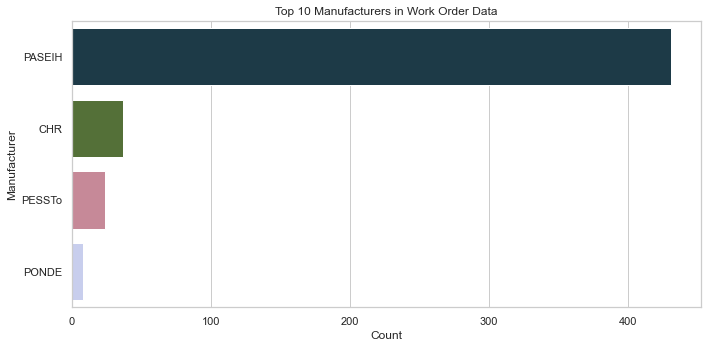

In [17]:
df = pd.read_excel(r"C:\Users\karthika\Downloads\Data for Task 2.xlsx", sheet_name='Work Order Data')

# Set plot style
sns.set(style="whitegrid")

# Plot Top 10 Manufacturers
plt.figure(figsize=(10, 5))
top_manufacturers = df['Manufacturer'].value_counts().head(10)
sns.barplot(x=top_manufacturers.values, y=top_manufacturers.index, palette='cubehelix')
plt.title("Top 10 Manufacturers in Work Order Data")
plt.xlabel("Count")
plt.ylabel("Manufacturer")
plt.tight_layout()
plt.show()
